# Rank Reversal Robustness of TOPSIS on the van Heerden (2021) Cryptocurrency Dataset

This notebook studies how robust a standard TOPSIS pipeline (`NegateMinimize` → `EntropyWeighter` → `VectorScaler` → `TOPSIS`) is to rank reversal, comparing two comparison window sizes (`Window Size 7` and `Window Size 15`) on the van Heerden et al. (2021) cryptocurrency evaluation dataset, using two complementary tests from `skcriteria.ranksrev`. The first, **RRT1** (`RankInvariantChecker`), controls degradations of every sub-optimal alternative and checks whether the ranking — especially the top choice — stays stable under these perturbations. The second, **RRT2/RRT3** (`RankTransitivityChecker`), decomposes the problem into all pairwise sub-comparisons, builds a dominance graph from them, and checks whether that graph is transitive (RRT2) and whether a ranking recomposed from the pairwise comparisons matches the original full-context ranking (RRT3). Together, the two experiments probe two different notions of ranking robustness — stability under perturbation and internal consistency under decomposition — and how each is affected by the choice of comparison window size.

## RRT1 Robustness Analysis: TOPSIS Sensitivity to Comparison Window Size

This experiment applies the **RankInvariantChecker** (Rank Reversal Test 1) to the
van Heerden et al. (2021) cryptocurrency evaluation dataset, comparing two different
comparison window sizes (`Window Size 7` and `Window Size 15`).

The decision-making pipeline is:

1. `NegateMinimize` — convert minimization criteria to maximization
2. `EntropyWeighter` — derive criteria weights from the information entropy of the data
3. `VectorScaler` — normalize the decision matrix
4. `TOPSIS` — rank alternatives by distance to the ideal solution

For each window size, `RankInvariantChecker` evaluates the reference ranking and then
generates controlled degradations of every suboptimal alternative, producing a
`RanksComparator` with one ranking per mutation. We use the comparator's built-in
analytical toolkit (`corr()`, `distance()`, `plot.flow()`, `plot.box()`,
`plot.heatmap()`) to assess how stable the TOPSIS ranking is under these perturbations,
and whether that stability differs between the two window sizes.

In [1]:
import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns

import skcriteria as skc
from skcriteria.preprocessing.invert_objectives import NegateMinimize, InvertMinimize
from skcriteria.preprocessing.scalers import VectorScaler, SumScaler
from skcriteria.preprocessing.weighters import (
    EntropyWeighter,
)
from skcriteria.pipelines import mkpipe
from skcriteria.agg.topsis import TOPSIS

from skcriteria.ranksrev import RankInvariantChecker, RankTransitivityChecker

sns.set_context("paper", font_scale=1.2, rc={"lines.linewidth": 1.5})

ws7 = skc.datasets.load_van2021evaluation(windows_size=7)
ws15 = skc.datasets.load_van2021evaluation(windows_size=15)

dm = mkpipe(
    NegateMinimize(),
    EntropyWeighter(),  
    VectorScaler(target="matrix"),        
    TOPSIS())

    
inv_chk = RankInvariantChecker(dm, random_state=42)

invchk_15 = inv_chk.evaluate(ws15)
invchk_7 = inv_chk.evaluate(ws7)


for name, res in [("ws=7", invchk_7), ("ws=15", invchk_15)]:
    print(f"{name}: OPR={res.extra_.opr:.3f}  RD={res.extra_.rd:.3f}")

ws=7: OPR=1.000  RD=0.000
ws=15: OPR=1.000  RD=0.000


Both window sizes achieve a perfect **Optimal Preservation Rate (OPR = 1.000)** and a **Rank Displacement of RD = 0.000**: across every controlled degradation of a sub-optimal alternative, BTC — the reference-ranking winner — never loses its first position. In other words, the *top choice* of the TOPSIS pipeline is fully robust to these perturbations regardless of the comparison window used. This tells us nothing yet, however, about what happens to the *rest* of the ranking, which is what the following plots explore.

----

### 1. Rank Distribution per Alternative

To look beyond the winner, we plot the distribution of ranks that each alternative takes across all mutation scenarios (one boxplot per alternative), comparing `Window Size 7` against `Window Size 15` side by side.

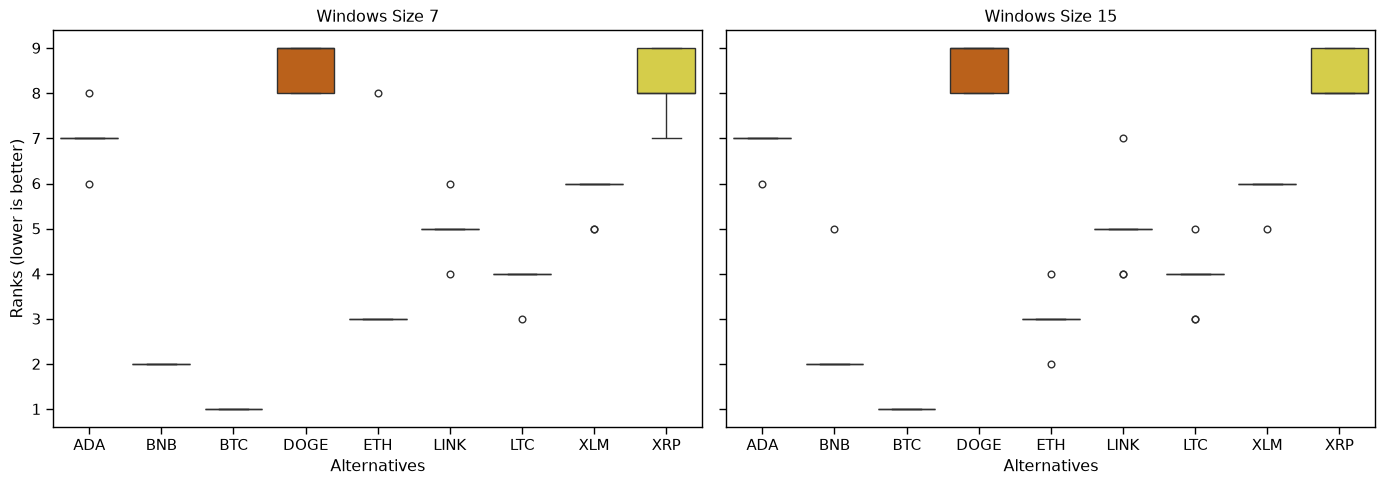

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

invchk_7.plot.box(ax=axes[0], palette="colorblind"); 
axes[0].set_title("Windows Size 7")

invchk_15.plot.box(ax=axes[1], palette="colorblind"); 
axes[1].set_title("Windows Size 15")

fig.tight_layout();
fig.savefig("../imgs/case1/rrt1_box.png", dpi=300)

In both windows, **BTC is perfectly pinned to rank 1** with zero spread across all nine scenarios, and in `Window Size 7` **BNB is equally pinned to rank 2**. Under `Window Size 15`, BNB shows a single outlier at rank 5 — precisely under its own degradation (`M.BNB`), the one scenario where weakening it is most likely to move it. The mid-tier alternatives (ETH, LTC, LINK, XLM, ADA) show a tight rank spread of at most ±2 in both windows, with the outlier typically appearing when that same alternative is the one being mutated. The bottom of the ranking is where TOPSIS is least decisive: **DOGE forms an actual interquartile box spanning ranks 8-9 in both windows** (its rank splits roughly 7/2 and 5/4 between 9 and 8 across the nine scenarios), and **XRP is the most volatile alternative overall**, ranging from 7 to 9 in `Window Size 7`. This suggests the closely-clustered worst alternatives (DOGE/XRP) are structurally more prone to order flips than the clearly-separated best ones (BTC/BNB), regardless of window size.

----

### 2. Correlation and Hamming Distance vs. the Reference Ranking

To quantify these visual impressions, we compute, for every mutation, its rank correlation and its normalized Hamming distance against the reference ranking, and present both as heatmaps for `Window Size 7` and `Window Size 15`.

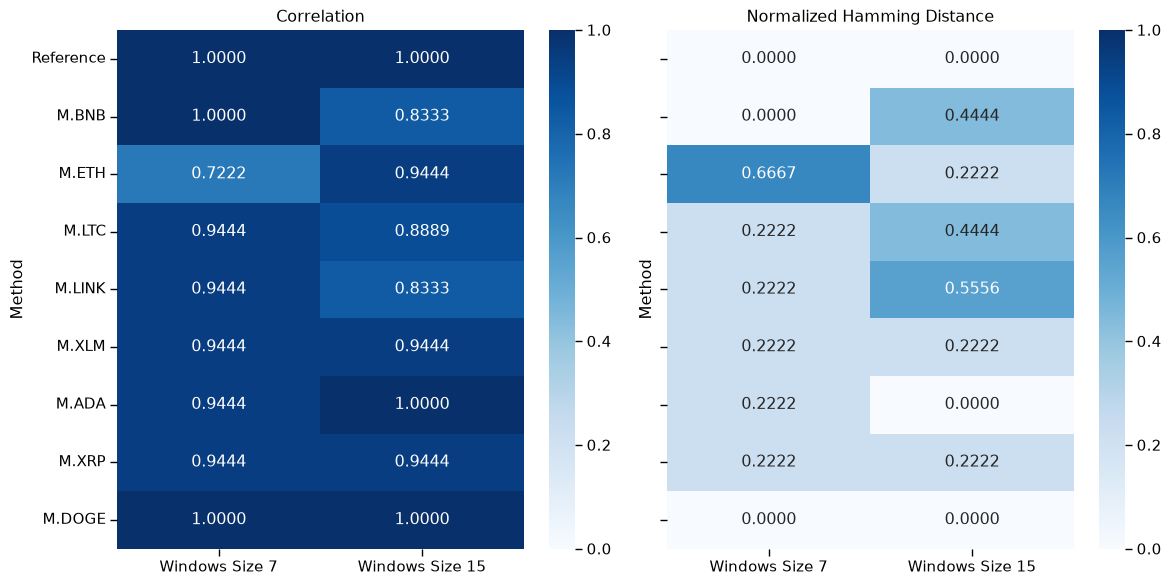

In [3]:
comp = pd.DataFrame({
    "corr_ws7": invchk_7.corr()["Reference"],
    "corr_ws15": invchk_15.corr()["Reference"],
    "dist_ws7": invchk_7.distance(metric="hamming")["Reference"],
    "dist_ws15": invchk_15.distance(metric="hamming")["Reference"],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

sns.heatmap(comp[["corr_ws7", "corr_ws15"]], annot=True, fmt=".4f",
            vmin=0, center=.5, vmax=1, ax=axes[0], cmap="Blues")
axes[0].set_xticklabels(["Windows Size 7", "Windows Size 15"])
axes[0].set_title("Correlation")

sns.heatmap(comp[["dist_ws7", "dist_ws15"]], annot=True, fmt=".4f",
            vmin=0, center=.5, vmax=1, ax=axes[1], cmap="Blues")
axes[1].set_xticklabels(["Windows Size 7", "Windows Size 15"])
axes[1].set_title("Normalized Hamming Distance")

plt.tight_layout()
fig.savefig("../imgs/case1/rrt1_corr_hamming_heatmap.png", dpi=300)
plt.show()

Interestingly, **the single most disruptive mutation is not the same for both window sizes**. Under `Window Size 7`, degrading ETH is by far the worst case (correlation drops to 0.722, Hamming distance rises to 0.667), while BNB and DOGE mutations leave the ranking completely untouched (correlation = 1, distance = 0) and the rest (LTC, LINK, XLM, ADA, XRP) cause only a single adjacent swap each (correlation = 0.944, distance = 0.222). Under `Window Size 15`, the picture is different: the ETH mutation becomes comparatively mild (correlation = 0.944, distance = 0.222 — just a swap with LTC), while **LINK is now the most disruptive mutation** (correlation = 0.833, distance = 0.556), closely followed by BNB and LTC (correlation = 0.833-0.889, distance = 0.444). ADA and DOGE mutations have no effect at all under `Window Size 15` (distance = 0). In short, both windows are similarly robust on average, but the *specific* alternative whose degradation is most dangerous for the overall ranking depends on the comparison window used.

----

### 3. Rank Heatmap per Mutation

For a finer-grained view, we plot the full rank matrix (alternatives x mutation) as a heatmap, showing the exact rank assigned to every alternative under every mutation scenario.

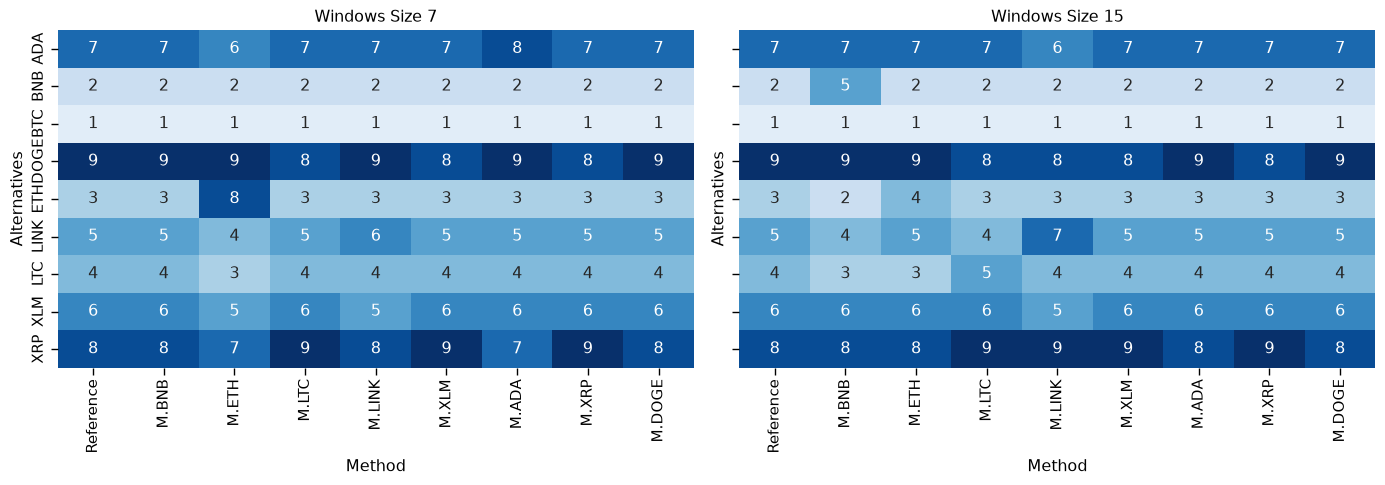

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

invchk_7.plot.heatmap(ax=axes[0], cbar=False, vmin=1, vmax=9, center=4.5, cmap="Blues")
axes[0].set_title("Windows Size 7")

invchk_15.plot.heatmap(ax=axes[1], cbar=False, vmin=1, vmax=9, center=4.5, cmap="Blues")
axes[1].set_title("Windows Size 15")

plt.tight_layout()
fig.savefig("../imgs/case1/rrt1_rank_heatmap.png", dpi=300)
plt.show()

The heatmap shows BTC (row fixed at 1) and, in `Window Size 7`, BNB (fixed at 2) as essentially untouchable, consistent with the OPR/RD results above. In `Window Size 7`, the **`M.ETH` column is the clear outlier**: ETH itself is pushed from rank 3 to rank 8, and every alternative that used to sit between those two positions (ADA, LINK, LTC, XLM, XRP) shifts up by exactly one slot to make room, while BTC/BNB/DOGE stay put. In `Window Size 15`, that same `M.ETH` column only swaps ETH with LTC — instead it is the **`M.LINK` column that reshuffles the most**: LINK drops from rank 5 to 7, pulling ADA (7→6), XLM (6→5), DOGE (9→8) and XRP (8→9) along with it. All the remaining columns, in both windows, only ever swap the mutated alternative with its immediate neighbour (or leave the ranking untouched), confirming that these localized rank flips at the bottom of the table — not the top — are the main source of instability in the RRT1 sensitivity test.

----

### 4. Rank Trajectories Across Mutations

Finally, we trace each alternative's rank as a connected trajectory across the full sequence of mutations (a "flow" diagram), which makes it easy to spot crossovers and see how far each alternative strays from its reference position, for both window sizes.

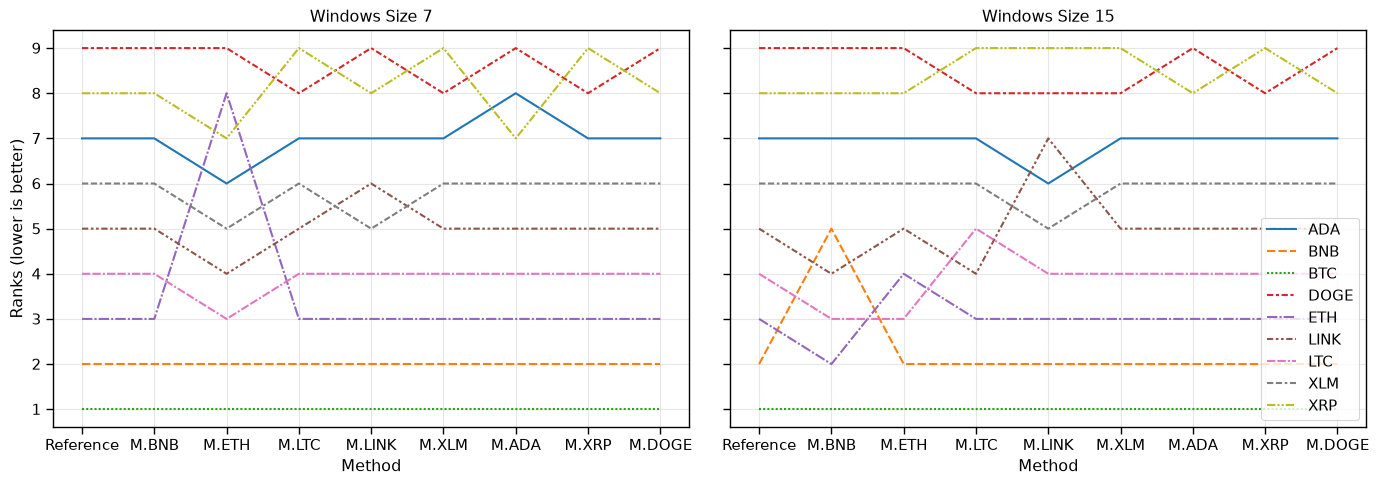

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

invchk_7.plot.flow(ax=axes[0], legend=False)
axes[0].set_title("Windows Size 7")

invchk_15.plot.flow(ax=axes[1])
axes[1].set_title("Windows Size 15")
axes[1].legend(loc="lower right")

plt.tight_layout()
fig.savefig("../imgs/case1/rrt1_flow.png", dpi=300)
plt.show()

The flow diagram confirms the picture built by the boxplots and heatmaps above, but makes the *shape* of each disruption directly visible as a trajectory. BTC (green) and, in `Window Size 7`, BNB (orange) trace a perfectly flat line at their reference rank across all nine mutations — the clearest visual evidence of their invariance; under `Window Size 15`, BNB's line dips once, from rank 2 to 5, exactly at its own degradation (`M.BNB`). The single most dramatic move in either panel is ETH's (purple) jump from rank 3 to rank 8 under `M.ETH` in `Window Size 7`, a trajectory that crosses LTC, LINK, XLM and XRP on the way down — the visual counterpart of the region-wide, one-slot shift described earlier. In `Window Size 15`, that same mutation barely registers (ETH dips only from 3 to 4); instead it is LINK's (brown) line that spikes hardest, from rank 5 to 7 under `M.LINK`, visibly dragging ADA, XLM, DOGE and XRP along with it. XRP (olive) is the noisiest trajectory in both panels, zigzagging between ranks 7-9 in `Window Size 7` and 8-9 in `Window Size 15`, and it repeatedly crosses DOGE (red) at the bottom of the plot as the two alternatives keep swapping the last position. Overall, the flow view reinforces that instability concentrates in the bottom half of the ranking (LINK through DOGE) and is driven almost entirely by whichever alternative is directly mutated, rather than by any systemic effect spanning all nine scenarios.

----

---
---

### RRT 2/3: Pairwise Dominance, Transitivity and Recomposition Consistency

While RRT1 measures robustness to controlled perturbations of the *original* decision matrix, this second experiment asks a different robustness question: is the TOPSIS ranking **internally consistent** with its own pairwise comparisons? `RankTransitivityChecker` decomposes the problem into all $\binom{9}{2}=36$ two-alternative sub-problems, evaluates each with the same pipeline, and assembles the results into a directed pairwise dominance ("tournament") graph. From this graph it checks:

- **RRT2 (transitivity, `test_criterion_2`)** — whether the dominance graph is acyclic, i.e. free of intransitive triples such as A ≻ B ≻ C ≻ A;
- **RRT3 (recomposition consistency, `test_criterion_3`)** — whether a ranking rebuilt purely from these pairwise comparisons (via a topological "generations" decomposition of the graph) matches the original full-context TOPSIS ranking.

In [6]:
trans_chk = RankTransitivityChecker(dm, n_jobs=-1)

trans_15 = trans_chk.evaluate(ws15)
trans_7 = trans_chk.evaluate(ws7)


### 1. Transitivity and Recomposition Summary

We first print the two aggregate diagnostics for each window size — whether RRT2 and RRT3 pass, the normalized transitivity break rate, and the maximum number of possible rankings (`mpr`) consistent with the pairwise dominance graph.

In [7]:
for title, res in [("Window Size 7", trans_7), ("Window Size 15", trans_15)]:
    e = res.extra_
    print(f"{title}: RRT2 (transitive)={e.test_criterion_2}  "
          f"trans_break_rate={e.transitivity_break_rate:.3f}  ",
          f"mpr={e.mpr}  "
          f"RRT3 (recomposition-consistent)={e.test_criterion_3}")

Window Size 7: RRT2 (transitive)=False  trans_break_rate=0.033   mpr=6  RRT3 (recomposition-consistent)=False
Window Size 15: RRT2 (transitive)=False  trans_break_rate=0.033   mpr=6  RRT3 (recomposition-consistent)=False


Both window sizes **fail RRT2** (`test_criterion_2=False`): the pairwise dominance graph contains at least one intransitive triple, so the tournament induced by TOPSIS is not a strict linear order. The break rate is small and identical for both windows (0.033, i.e. 1 out of the 30 theoretically possible 3-cycles for 9 alternatives), so this is a single isolated cycle rather than widespread inconsistency. Because RRT2 fails, **RRT3 automatically fails too** (`test_criterion_3=False`) — a ranking recomposed purely from pairwise sub-problems can never exactly match the original full-context ranking once a cycle forces a tie. `mpr=6` shows that, even after breaking that cycle, the dominance graph still admits up to 6 distinct valid linear extensions, i.e. genuine ranking ambiguity remains after decomposition. Strikingly, **all four numbers are identical for `Window Size 7` and `Window Size 15`**, suggesting that this particular intransitivity is not sensitive to the comparison window — unlike the RRT1 mutation sensitivity, which clearly differed between windows.

---

### 2. Original vs. Recomposed Ranking Agreement

To quantify how far the recomposed ranking drifts from the original, we compute the rank correlation and normalized Hamming distance between the `Original` ranking and the `Recomposition.generations` ranking, for both window sizes.

In [8]:
comp = pd.DataFrame({
    "corr": [trans_7.corr().loc["Original"].iloc[1],
             trans_15.corr().loc["Original"].iloc[1]],
    "hamming_dist": [trans_7.distance(metric="hamming").loc["Original"].iloc[1],
                      trans_15.distance(metric="hamming").loc["Original"].iloc[1]],
}, index=["Window Size 7", "Window Size 15"])
comp

,corr,hamming_dist
Window Size 7,0.841375,0.777778
Window Size 15,0.957427,0.777778


The normalized Hamming distance between the original and recomposed rankings is **identical for both windows (0.778)** — 7 out of 9 alternatives change position once the ranking is rebuilt from pairwise comparisons. The rank correlation, however, is **not** identical: `Window Size 7` drops to 0.841 while `Window Size 15` stays higher at 0.957, meaning that although the same number of alternatives move, they move by a *smaller* amount on average under `Window Size 15`. This is the clearest evidence so far that recomposing the ranking from pairwise sub-problems produces a materially different ranking than the original full-context TOPSIS evaluation — a decomposition/recomposition rank reversal — and that its severity (though not its footprint) depends on the comparison window.

----

### 3. Rank Heatmap: Original vs. Recomposed

We now look at the exact rank each alternative takes in the `Original` ranking versus its `Recomposition.generations` counterpart, alongside a printout of the specific transitivity-violating cycle(s) found for each window size.

Window Size 7: 1 violation(s)
   >['BNB', 'LTC', 'ETH']>BNB
Window Size 15: 1 violation(s)
   >['BNB', 'LTC', 'ETH']>BNB


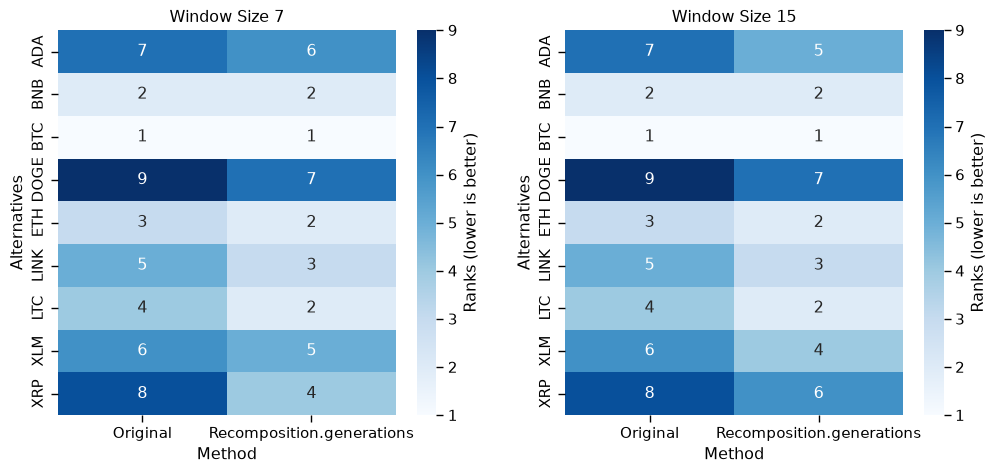

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
trans_7.plot.heatmap(ax=axes[0], cmap="Blues"); axes[0].set_title("Window Size 7")
trans_15.plot.heatmap(ax=axes[1], cmap="Blues"); axes[1].set_title("Window Size 15")

fig.savefig("../imgs/case1/rrt23_recomposition_heatmap.png", dpi=300)

for title, res in [("Window Size 7", trans_7), ("Window Size 15", trans_15)]:
    breaks = res.extra_.transitivity_break
    print(f"{title}: {len(breaks)} violation(s)")
    for b in breaks:
        print("  ", b[0])

Both windows report **exactly the same single violation: `BNB > LTC > ETH > BNB`** — a 3-way cycle among the three alternatives that sit just below BTC in the reference ranking. Its effect is directly visible in the heatmap: BNB, ETH and LTC (ranks 2, 3, 4 in the `Original` column) all collapse to the **same tied rank 2** in `Recomposition.generations`, since a cyclic triple has no valid linear order and the generations algorithm places all three in one topological layer. This tie frees up rank slots for everyone below: LINK, XLM, ADA, XRP and DOGE all move to a better (lower) rank than in the original ranking. `XRP` shows the largest swing **between the two windows** — rank 4 under `Window Size 7` versus rank 6 under `Window Size 15`, a two-position difference — while ADA and XLM shift by only one position each (6→5 and 5→4); these three are the only alternatives whose recomposed position is not window-invariant. BTC (rank 1) again remains completely untouched.

----

### 4. Condensed Dominance DAG

Finally, we visualize the **condensed, transitively-reduced DAG** derived from the pairwise dominance graph: each node is a strongly-connected component of the tournament (a single alternative, or a group tied together by a cycle), and an arrow $A \to B$ means $A$ strictly dominates $B$. Read left-to-right, this chain is literally how the `Recomposition.generations` ranking discussed above was built.

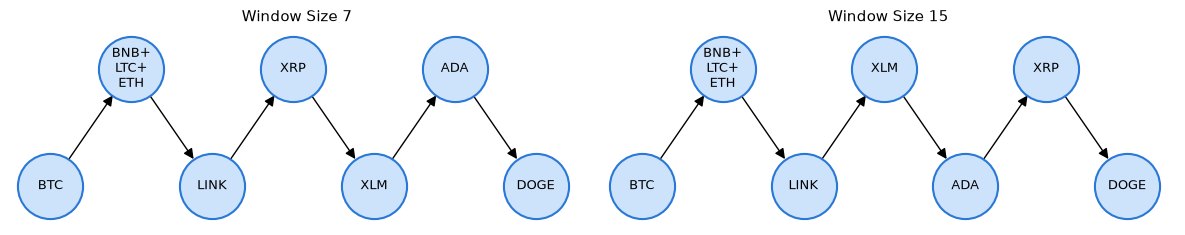

In [10]:
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))
for ax, (title, res) in zip(axes, [("Window Size 7", trans_7), ("Window Size 15", trans_15)]):
    g = res.extra_.dag
    order = list(nx.topological_sort(g))
    pos = {node: (i, 0.3 * (i % 2)) for i, node in enumerate(order)}
    nx.draw(g, pos=pos, ax=ax, with_labels=True, node_color="#cde2fb",
             edgecolors="#2a78d6", linewidths=1.5,
             arrowsize=15, node_size=2200, font_size=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-0.5, len(order) - 0.4)
    ax.set_ylim(-.1, .4)

fig.tight_layout()
fig.savefig("../imgs/case1/rrt23_dominance_graph.png", dpi=300)

Both DAGs collapse into a single chain running from BTC down to DOGE — exactly the top and bottom of the `Original` ranking — with one node per alternative except for a single merged node partway down. This confirms visually that almost the entire tournament is a strict order: only one strongly-connected component contains more than one alternative, consistent with the low transitivity break rate (0.033) reported earlier.

----

The one node that isn't a single alternative is the merged **BNB+LTC+ETH** node: these three form a 3-cycle in the raw pairwise dominance graph (`BNB → LTC → ETH → BNB`), so they cannot be placed in a strict order relative to one another, and the condensation collapses them into a single strongly-connected component — exactly why all three come out **tied to the same rank** in the recomposed ranking above. Everything downstream of that node is where the two window sizes start to differ: in `Window Size 7` the chain continues `LINK → XRP → XLM → ADA → DOGE`, while in `Window Size 15` it is `LINK → XLM → ADA → XRP → DOGE` — XRP moving two steps later in the chain is exactly the two-rank swing (4 vs. 6) noted earlier.

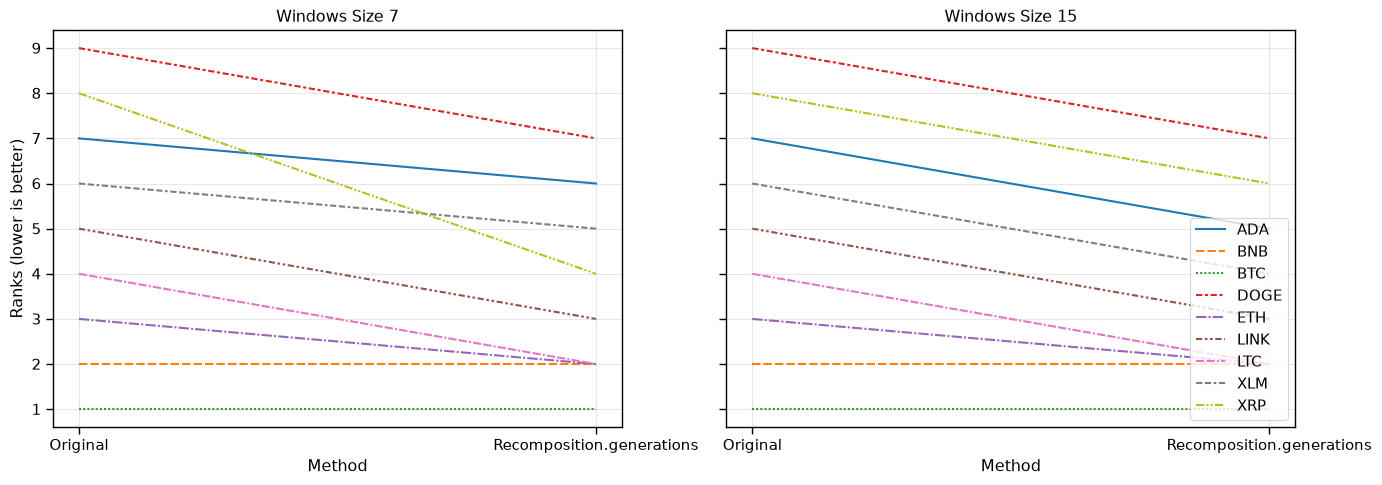

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

trans_7.plot.flow(ax=axes[0], legend=False)
axes[0].set_title("Windows Size 7")

trans_15.plot.flow(ax=axes[1])
axes[1].set_title("Windows Size 15")
axes[1].legend(loc="lower right")

plt.tight_layout()
fig.savefig("../imgs/case1/rrt23_flow.png", dpi=300)
plt.show()

The flow diagram makes the same story visible as a trajectory: BNB, ETH and LTC (orange, teal and blue) start at different ranks (2, 3 and 4) but **converge onto the exact same point** at `Recomposition.generations`, visually confirming the three-way tie caused by the cycle. XRP (magenta) is again the most dramatic mover, crossing ADA, DOGE, XLM and LINK on its way from rank 8 down to rank 4 (`Window Size 7`) or 6 (`Window Size 15`) — the steepest slope in either panel, and the main reason the two windows differ in overall correlation with the original ranking even though they share the exact same transitivity violation.